In [ ]:
import os.path as osp
import sys
sys.path.append('../')
import torch
from torch.utils.data import DataLoader

import numpy as np
from tqdm.notebook import tqdm

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import utils
from utils.plotting import get_scores

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#DEVICE = 'cpu'
print(DEVICE)

cuda:0


/home/mdrnevich/test/QuasiDRE/ToyModels/../utils/__init__.py:4: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. If it still does not work, please check the documentation at https://plothist.readthedocs.io/en/latest/usage/font_installation.html
  from . import plotting


In [ ]:
"""
Dataset options: pos_only, mc, negative
"""

DATA_DIR = "./data/"
SAVE_DIR = "./models/"
DATASET = "mc"

FLOATING_TYPE = torch.float64 # use double precision for better numerical stability for PARE loss - it's unstable otherwise

source_mixture_coef = (4, -1)
source_scales = (2.5, 2.3)
target_mixture_coef = (2, -1)
if DATASET == "negative":
    target_scales = (2, 1.2)
else:
    target_scales = (2, 1.42)


if DATASET == "pos_only":
    source_file = osp.join(DATA_DIR, "base_distribution_data")
elif DATASET == "mc":
    source_file = osp.join(DATA_DIR, "base_distribution_mc_data")
target_file = osp.join(DATA_DIR, "target_distribution_mc_data")

In [4]:
batch_size = int(2**8)
model_paths = [osp.join(SAVE_DIR, "classifier_subdensity_{}_batch{}.zip".format(i+1, batch_size)) for i in range(4)]
training_settings = [utils.train.load_training_settings(model_path) for model_path in model_paths]
X_scalers, weight_norms = list(zip(*[utils.preprocessing.load_scaling(model_path) for model_path in model_paths]))
models = [utils.models.load_model(model_path, device=DEVICE).to(DEVICE) for model_path in model_paths]

In [5]:
source_positive_file = source_file + "_positives"
source_negative_file = source_file + "_negatives"
target_positive_file = target_file + "_positives"
target_negative_file = target_file + "_negatives"

files = [source_positive_file, source_negative_file, target_positive_file, target_negative_file]

sum_weights = []
for f in files:
    sum_weights.append(np.load(f + "_train.npy")[:,-1].sum())

sum_weights = np.array(sum_weights)
sum_weights

array([1600782., -399218., 1334428., -665572.])

In [6]:
coefficient_init = [sum_weights[0] / sum_weights[:2].sum(), sum_weights[2] / sum_weights[2:].sum()]
coefficient_init

[np.float64(1.3322486359444856), np.float64(1.9950901240326766)]

In [7]:
training_settings = {}

"""
There is one dataset generated using Powheg + Pythia8
and another generated using Sherpa
"""

t0 = 25619
t1 = 58
print(t0, t1, -(t0/t1)**2, -t0/t1)


MIN_TRAIN_SIZE = int(min([np.load(source_file + "_train.npy").shape[0], np.load(target_file + "_train.npy").shape[0]]))
MIN_VALID_SIZE = int(min([np.load(source_file + "_val.npy").shape[0], np.load(target_file + "_val.npy").shape[0]]))

train_base_dataset = utils.preprocessing.Dataset(source_file + "_train.npy", 0, stop_event=MIN_TRAIN_SIZE)
valid_base_dataset = utils.preprocessing.Dataset(source_file + "_val.npy", 0, stop_event=MIN_VALID_SIZE)

train_target_dataset = utils.preprocessing.Dataset(target_file + "_train.npy", 1, stop_event=MIN_TRAIN_SIZE)
valid_target_dataset = utils.preprocessing.Dataset(target_file + "_val.npy", 1, stop_event=MIN_VALID_SIZE)


training_settings.update({
    "source_file": source_file,
    "target_file": target_file,
})

25619 58 -195104.9824613555 -441.7068965517241


In [8]:
source_weight_norm = train_base_dataset.process(normalize_weights=True)
valid_base_dataset.process(normalize_weights=True)#, weight_norm=source_weight_norm)

target_weight_norm = train_target_dataset.process(normalize_weights=True)
valid_target_dataset.process(normalize_weights=True)#, weight_norm=target_weight_norm)

tensor(0.3339)

In [9]:
train_generator_data = utils.preprocessing.CombinedDataset(train_base_dataset, train_target_dataset)
valid_generator_data = utils.preprocessing.CombinedDataset(valid_base_dataset, valid_target_dataset)

In [10]:
X_scaler, weight_norm = utils.preprocessing.get_scaling(train_generator_data)
print(weight_norm)

100%|██████████| 3907/3907 [00:16<00:00, 241.48it/s]

tensor(1.0000)


In [11]:
batch_size = 1024
train_loader = DataLoader(train_generator_data, batch_size=batch_size, shuffle=False)
train_nominal_loader = DataLoader(utils.preprocessing.CombinedDataset(train_base_dataset), batch_size=batch_size, shuffle=False)
train_alternative_loader = DataLoader(utils.preprocessing.CombinedDataset(train_target_dataset), batch_size=batch_size, shuffle=False)

In [12]:
train_scores, train_targets, train_weights = list(zip(*[get_scores(
    models[i],
    train_loader,
    X_scalers[i],
    leave=True,
    device=DEVICE
) for i in range(4)]))

100%|██████████| 3907/3907 [00:28<00:00, 135.52it/s]


In [53]:
train_subratios = [torch.tensor((1-train_scores[i]) / train_scores[i], dtype=FLOATING_TYPE) for i in range(4)]
targets = torch.from_numpy(train_targets[0])
weights = torch.from_numpy(train_weights[0]) / weight_norm

In [54]:
def get_total_ratio(c0, c1, ratios):
    part1 = (c0 / c1) * ratios[0]
    part2 = ((1 - c0) / c1) * ratios[2]
    part3 = (c0 / (1 - c1)) * ratios[1]
    part4 = ((1 - c0) / (1 - c1)) * ratios[3]
    total_ratio = 1/(part1+part2) + 1/(part3+part4)
    return total_ratio #q(Y=1)/q(Y=0)

In [55]:
_ = get_total_ratio(*coefficient_init, train_subratios)
print(_.min(), _.max())
#np.testing.assert_almost_equal(1/_, _2)
_

tensor(-1.2252, dtype=torch.float64) tensor(1.8147, dtype=torch.float64)


tensor([ 1.0721,  1.8085,  1.4439,  ...,  1.0859, -0.2922,  1.3997],
       dtype=torch.float64)

In [56]:
def get_pare_loss(ratios, targets, weights, t0=t0, t1=t1):
    s = torch.where(torch.isinf(ratios), 1/t1, (t0 + t1 * ratios) / (t0**2 + t1**2 * ratios))
    # s = torch.from_numpy((t0 + t1 * ratios) / (t0**2 + t1**2 * ratios))
    return (utils.train.pare_loss(s, targets, t0, t1)*weights).mean().cpu().item()

def get_revert_loss(ratios, targets, weights):
    s = torch.where(ratios == 0, 0.5, (ratios + 2 - torch.sqrt(ratios**2 + 4)) / (2*ratios)) 
    # s = torch.from_numpy(ratios / (1 + ratios))
    return (utils.train.revert_loss(s, targets)*weights).mean().cpu().item()

In [57]:
N = 200
pare_losses0 = np.zeros(N)
x = np.linspace(coefficient_init[0]-1, coefficient_init[0]+0.5, N)

for i, c0 in tqdm(enumerate(x), total=N):
    ratios = get_total_ratio(c0, coefficient_init[1], train_subratios)
    pare_losses0[i] = get_pare_loss(ratios, targets, weights, t0=t0, t1=t1)
pare_losses0 = np.array(pare_losses0)

  0%|          | 0/200 [00:00<?, ?it/s]

In [58]:
pare_vmin0 = np.argmin(np.nan_to_num(pare_losses0, nan=np.inf, neginf=np.inf))
x[pare_vmin0], pare_losses0[pare_vmin0]

(np.float64(1.070942103281169), np.float64(0.49773539430686936))

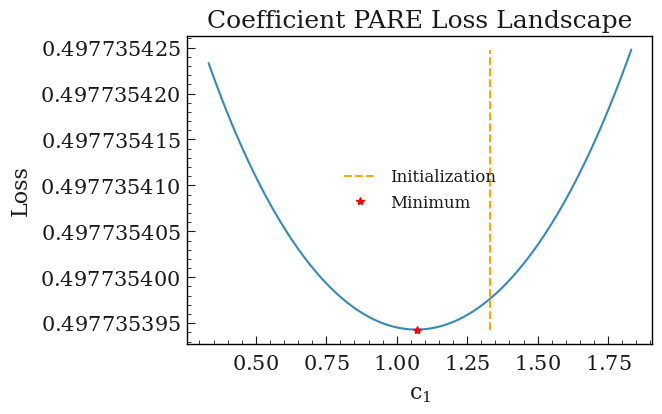

In [59]:
plt.plot(x, pare_losses0)
plt.plot([coefficient_init[0], coefficient_init[0]],
         [np.nan_to_num(pare_losses0, nan=np.inf, neginf=np.inf).min(),
          np.nan_to_num(pare_losses0, nan=-np.inf, posinf=-np.inf).max()], '--', c='orange', label="Initialization")
plt.plot(x[pare_vmin0], pare_losses0[pare_vmin0], '*', c='red', label="Minimum")
plt.xlabel("$c_1$", size=16)
plt.ylabel("Loss", size=16)
plt.title("Coefficient PARE Loss Landscape", size=18)
plt.legend()

In [60]:
N = 200
revert_losses0 = np.zeros(N)
x = np.linspace(coefficient_init[0]-1, coefficient_init[0]+0.5, N)

for i, c0 in tqdm(enumerate(x), total=N):
    ratios = get_total_ratio(c0, coefficient_init[1], train_subratios)
    revert_losses0[i] = get_revert_loss(ratios, targets, weights)

revert_losses0 = np.array(revert_losses0)

  0%|          | 0/200 [00:00<?, ?it/s]

In [61]:
revert_vmin0 = np.argmin(np.nan_to_num(revert_losses0, nan=np.inf, neginf=np.inf))
x[revert_vmin0], revert_losses0[revert_vmin0]

(np.float64(1.055866726396747), np.float64(0.898588205468637))

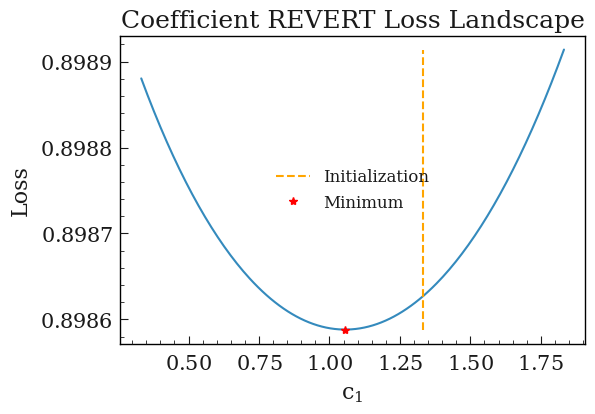

In [62]:
plt.plot(x, revert_losses0)
plt.plot([coefficient_init[0], coefficient_init[0]],
         [np.nan_to_num(revert_losses0, nan=np.inf, neginf=np.inf).min(),
          np.nan_to_num(revert_losses0, nan=-np.inf, posinf=-np.inf).max()], '--', c='orange', label="Initialization")
plt.plot(x[revert_vmin0], revert_losses0[revert_vmin0], '*', c='red', label="Minimum")
plt.xlabel("$c_1$", size=16)
plt.ylabel("Loss", size=16)
plt.title("Coefficient REVERT Loss Landscape", size=18)
plt.legend()

In [63]:
N = 200
pare_losses1 = np.zeros(N)
y = np.linspace(coefficient_init[1]-1, coefficient_init[1]+1, N)

for i, c1 in tqdm(enumerate(y), total=N):
    ratios = get_total_ratio(coefficient_init[0], c1, train_subratios)
    pare_losses1[i] = get_pare_loss(ratios, targets, weights, t0=t0, t1=t1)

pare_losses1 = np.array(pare_losses1)

  0%|          | 0/200 [00:00<?, ?it/s]

In [64]:
pare_vmin1 = np.argmin(np.nan_to_num(pare_losses1, nan=np.inf, neginf=np.inf))
y[pare_vmin1]

np.float64(1.9800147471482545)

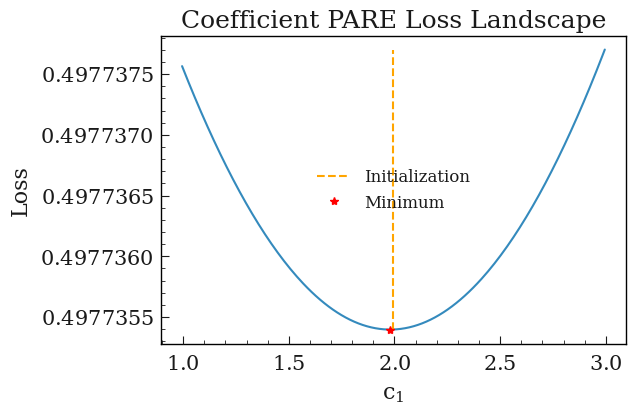

In [65]:
plt.plot(y, pare_losses1)
plt.plot([coefficient_init[1], coefficient_init[1]],
         [np.nan_to_num(pare_losses1, nan=np.inf, neginf=np.inf).min(),
          np.nan_to_num(pare_losses1, nan=-np.inf, posinf=-np.inf).max()], '--', c='orange', label="Initialization")
plt.plot(y[pare_vmin1], pare_losses1[pare_vmin1], '*', c='red', label="Minimum")
plt.xlabel("$c_1$", size=16)
plt.ylabel("Loss", size=16)
plt.title("Coefficient PARE Loss Landscape", size=18)
plt.legend()

## Do a 2D scan

In [66]:
N = 40
pare_losses = np.zeros((N,N))
x = np.linspace(coefficient_init[0]-1, coefficient_init[0]+1, N)
y = np.linspace(coefficient_init[1]-1, coefficient_init[1]+1, N)

for i, c0 in tqdm(enumerate(x), total=N):
    for j, c1 in tqdm(enumerate(y), total=N, leave=False):
        ratios = get_total_ratio(c0, c1, train_subratios)
        pare_losses[i,j] = get_pare_loss(ratios, targets, weights, t0=t0, t1=t1)

pare_losses = np.array(pare_losses)

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

...

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

In [67]:
pare_vmin = np.nanmin(pare_losses[~np.isinf(pare_losses)])
pare_vmax = np.nanmax(pare_losses[~np.isinf(pare_losses)])
pare_vmin, pare_vmax

(np.float64(0.4977353947376795), np.float64(0.4977390114281034))

In [68]:
pare_argmin = np.argmin(np.nan_to_num(pare_losses, nan=pare_vmax, posinf=pare_vmax, neginf=pare_vmax))
x[pare_argmin//N], y[pare_argmin%N]

(np.float64(1.1014794051752546), np.float64(1.9694490983916508))

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_250778/3705182230.py:12: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("Signed LR Application - $\mathcal{L}_{PARE}$ Loss Landscape", fontsize=18)


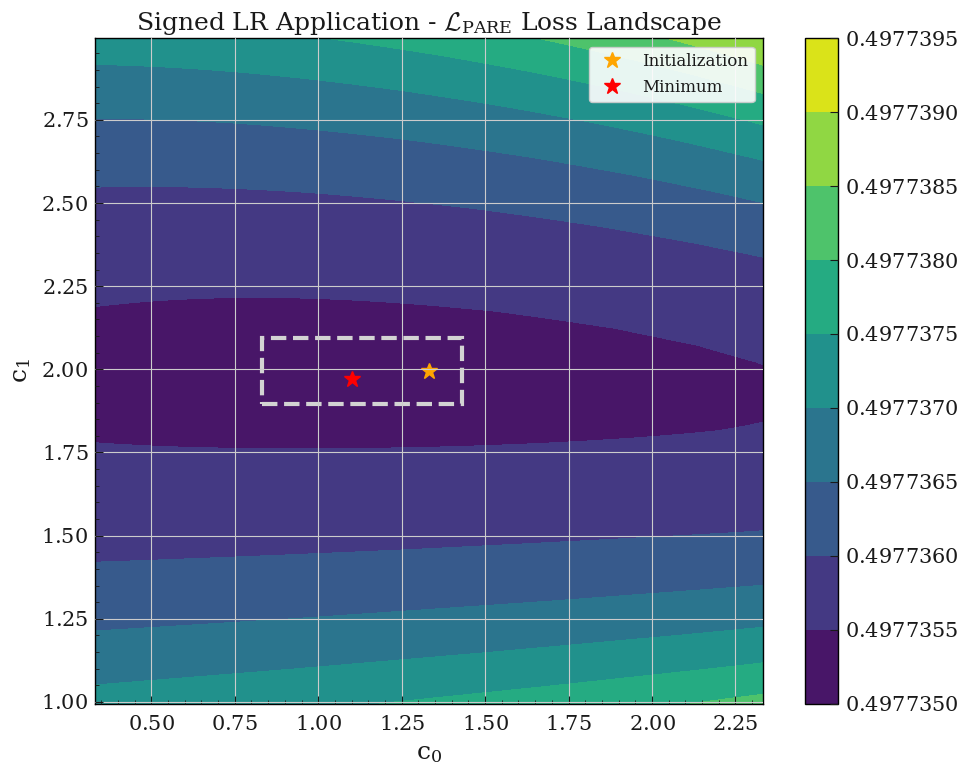

In [69]:
fig, ax = plt.subplots()
fig.set_size_inches(10,8)

xx, yy = np.meshgrid(x,y)
im = ax.contourf(xx, yy, pare_losses.T)#, levels=np.linspace(-1e6, 1e6, 15))
ax.plot(*coefficient_init, '*', c='orange', label="Initialization", markersize='12')
ax.plot(x[pare_argmin//N], y[pare_argmin%N], '*', c='red', label="Minimum", markersize='12')
rect = patches.Rectangle((coefficient_init[0]-0.5, coefficient_init[1]-0.1), 0.6, 0.2, linewidth=3, edgecolor='lightgray', linestyle='--', facecolor='none')
ax.add_patch(rect)
ax.set_xlabel('$c_0$')
ax.set_ylabel('$c_1$')
ax.set_title("Signed LR Application - $\mathcal{L}_{PARE}$ Loss Landscape", fontsize=18)
ax.grid()
ax.legend(frameon=True, framealpha=0.9)
fig.colorbar(im, ax=ax)

fig.tight_layout()

In [70]:
N = 40
revert_losses = np.zeros((N,N))
x = np.linspace(coefficient_init[0]-1, coefficient_init[0]+1, N)
y = np.linspace(coefficient_init[1]-1, coefficient_init[1]+1, N)

for i, c0 in tqdm(enumerate(x), total=N):
    for j, c1 in tqdm(enumerate(y), total=N, leave=False):
        ratios = get_total_ratio(c0, c1, train_subratios)
        revert_losses[i,j] = get_revert_loss(ratios, targets, weights)

revert_losses = np.array(revert_losses)

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

...

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

In [71]:
mse_vmin = np.nanmin(revert_losses[~np.isinf(revert_losses)])
mse_vmax = np.nanmax(revert_losses[~np.isinf(revert_losses)])
mse_vmin, mse_vmax

(np.float64(0.8985912273303813), np.float64(0.9259034933052779))

In [72]:
mse_argmin = np.argmin(np.nan_to_num(revert_losses, nan=mse_vmax, posinf=mse_vmax, neginf=mse_vmax))
x[mse_argmin//N], y[mse_argmin%N]

(np.float64(1.1014794051752546), np.float64(1.9694490983916508))

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_250778/106613912.py:12: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("Signed LR Application - $\mathcal{L}_{REVERT}$ Loss Landscape", fontsize=18)


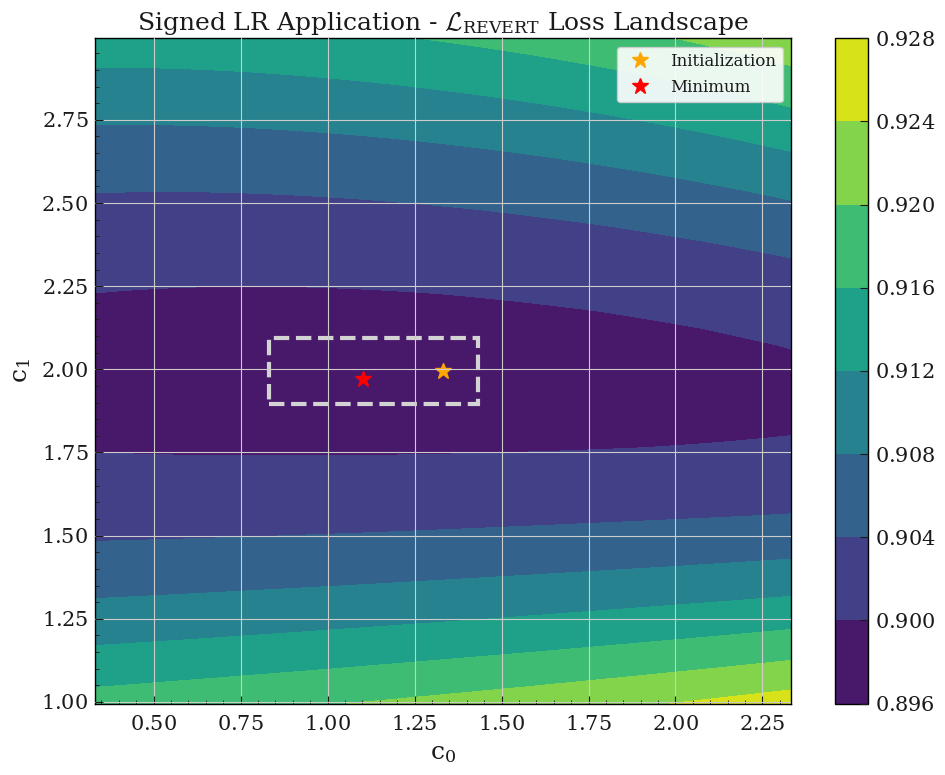

In [73]:
fig, ax = plt.subplots()
fig.set_size_inches(10,8)

xx, yy = np.meshgrid(x,y)
im = ax.contourf(xx, yy, revert_losses.T)#, levels=np.linspace(-1e6, 1e6, 15))
ax.plot(*coefficient_init, '*', c='orange', label="Initialization", markersize='12')
ax.plot(x[mse_argmin//N], y[mse_argmin%N], '*', c='red', label="Minimum", markersize='12')
rect = patches.Rectangle((coefficient_init[0]-0.5, coefficient_init[1]-0.1), 0.6, 0.2, linewidth=3, edgecolor='lightgray', linestyle='--', facecolor='none')
ax.add_patch(rect)
ax.set_xlabel('$c_0$')
ax.set_ylabel('$c_1$')
ax.set_title("Signed LR Application - $\mathcal{L}_{REVERT}$ Loss Landscape", fontsize=18)
ax.grid()
ax.legend(frameon=True, framealpha=0.9)
fig.colorbar(im, ax=ax)

fig.tight_layout()

## Now do a zoomed-in version

In [74]:
N = 40
pare_losses2 = np.zeros((N,N))
x2 = np.linspace(coefficient_init[0]-0.5, coefficient_init[0]+0.1, N)
y2 = np.linspace(coefficient_init[1]-0.1, coefficient_init[1]+0.1, N)

for i, c0 in enumerate(x2):
    for j, c1 in enumerate(y2):
        ratios = get_total_ratio(c0, c1, train_subratios)
        pare_losses2[i,j] = get_pare_loss(ratios, targets, weights, t0=t0, t1=t1)

pare_losses2 = np.array(pare_losses2)

In [75]:
pare_vmin2 = np.nanmin(pare_losses2[~np.isinf(pare_losses2)])
pare_vmax2 = np.nanmax(pare_losses2[~np.isinf(pare_losses2)])
pare_vmin2, pare_vmax2

(np.float64(0.4977353941490448), np.float64(0.49773543233182255))

In [76]:
pare_argmin2 = np.argmin(np.nan_to_num(pare_losses2, nan=pare_vmax2, posinf=pare_vmax2, neginf=pare_vmax2))
x2[pare_argmin2//N], y2[pare_argmin2%N]

(np.float64(1.0784024820983318), np.float64(1.9873978163403687))

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_250778/3942094600.py:11: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("Signed LR Application - $\mathcal{L}_{PARE}$ Loss Landscape", fontsize=20)
/tmp/ipykernel_250778/3942094600.py:13: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("Nonnegative LR Application - $\mathcal{L}_{PARE}$ Loss Landscape", fontsize=20)


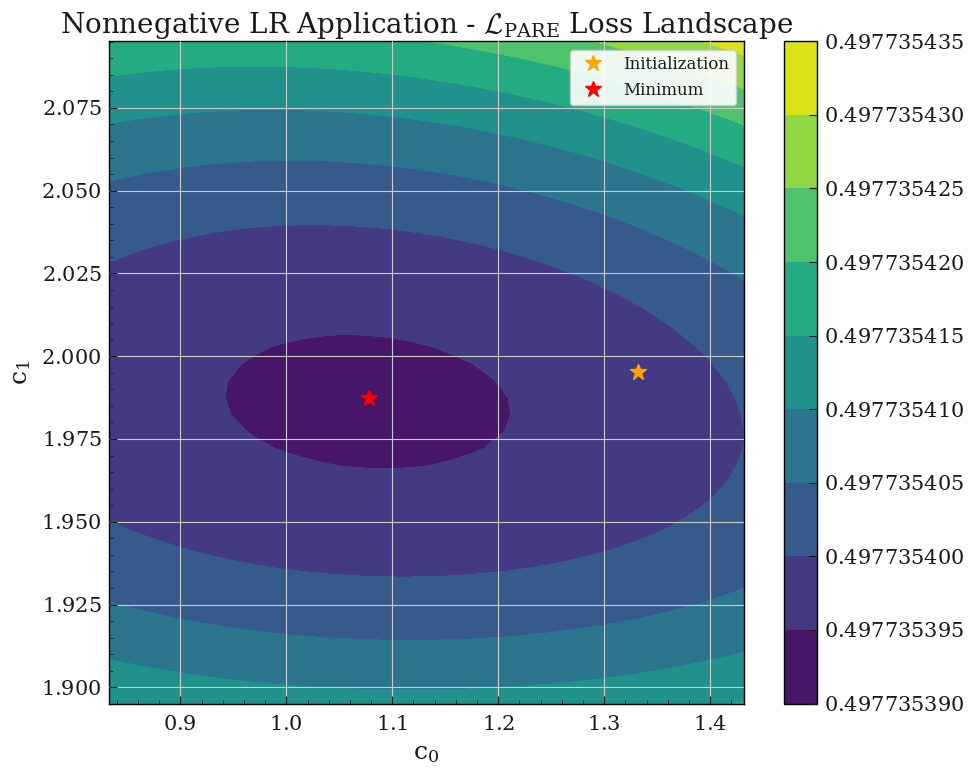

In [77]:
fig, ax = plt.subplots()
fig.set_size_inches(10,8)

xx, yy = np.meshgrid(x2,y2)
im = ax.contourf(xx, yy, pare_losses2.T)#, levels=np.linspace(-1e6, 1e6, 15))
ax.plot(*coefficient_init, '*', c='orange', label="Initialization", markersize='12')
ax.plot(x2[pare_argmin2//N], y2[pare_argmin2%N], '*', c='red', label="Minimum", markersize='12')
ax.set_xlabel('$c_0$')
ax.set_ylabel('$c_1$')
if DATASET == "negative":
    ax.set_title("Signed LR Application - $\mathcal{L}_{PARE}$ Loss Landscape", fontsize=20)
if DATASET == "mc":
    ax.set_title("Nonnegative LR Application - $\mathcal{L}_{PARE}$ Loss Landscape", fontsize=20)
ax.grid()
ax.legend(frameon=True, framealpha=0.9)
fig.colorbar(im, ax=ax)

fig.tight_layout()

In [78]:
N = 40
revert_losses2 = np.zeros((N,N))
x2 = np.linspace(coefficient_init[0]-0.5, coefficient_init[0]+0.1, N)
y2 = np.linspace(coefficient_init[1]-0.1, coefficient_init[1]+0.1, N)

for i, c0 in enumerate(x2):
    for j, c1 in enumerate(y2):
        ratios = get_total_ratio(c0, c1, train_subratios)
        revert_losses2[i,j] = get_revert_loss(ratios, targets, weights)

revert_losses2 = np.array(revert_losses2)

In [79]:
revert_vmin2 = np.nanmin(revert_losses2[~np.isinf(revert_losses2)])
revert_vmax2 = np.nanmax(revert_losses2[~np.isinf(revert_losses2)])
revert_vmin2, revert_vmax2

(np.float64(0.8985859294326211), np.float64(0.8989951952452506))

In [80]:
revert_argmin2 = np.argmin(np.nan_to_num(revert_losses2, nan=revert_vmax2, posinf=revert_vmax2, neginf=revert_vmax2))
x2[revert_argmin2//N], y2[revert_argmin2%N]

(np.float64(1.0630178667137165), np.float64(1.9822696112121636))

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_250778/3001061921.py:11: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("Signed LR Application - $\mathcal{L}_{REVERT}$ Loss Landscape", fontsize=20)
/tmp/ipykernel_250778/3001061921.py:13: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("Nonnegative LR Application - $\mathcal{L}_{REVERT}$ Loss Landscape", fontsize=20)


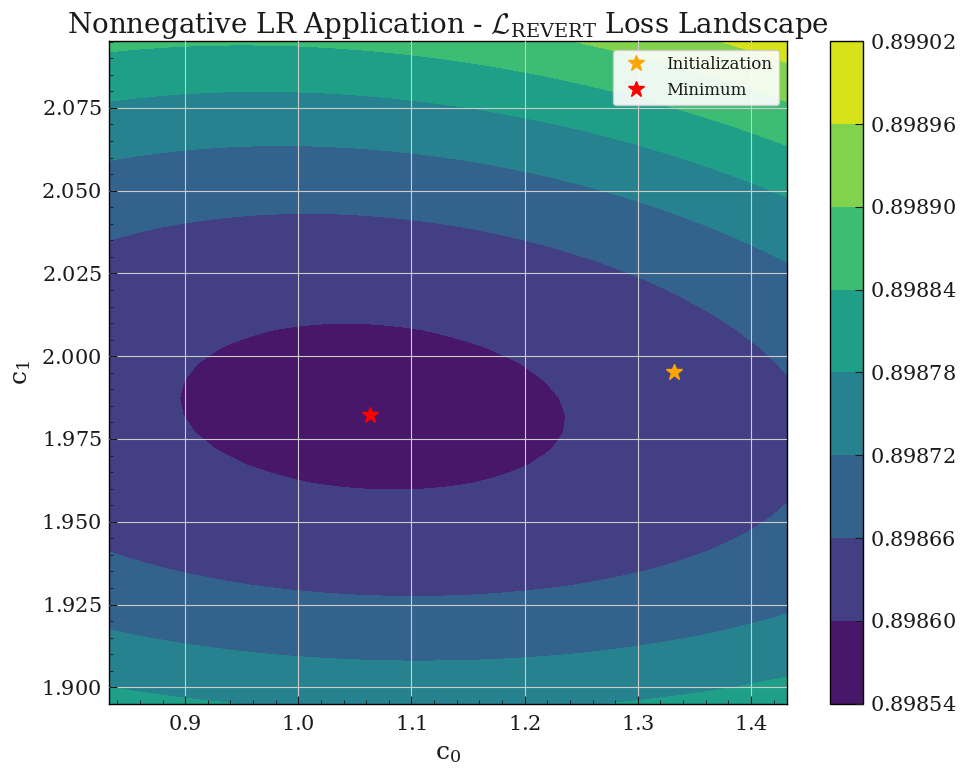

In [81]:
fig, ax = plt.subplots()
fig.set_size_inches(10,8)

xx, yy = np.meshgrid(x2,y2)
im = ax.contourf(xx, yy, revert_losses2.T)#, levels=np.linspace(-1e6, 1e6, 15))
ax.plot(*coefficient_init, '*', c='orange', label="Initialization", markersize='12')
ax.plot(x2[revert_argmin2//N], y2[revert_argmin2%N], '*', c='red', label="Minimum", markersize='12')
ax.set_xlabel('$c_0$')
ax.set_ylabel('$c_1$')
if DATASET == "negative":
    ax.set_title("Signed LR Application - $\mathcal{L}_{REVERT}$ Loss Landscape", fontsize=20)
if DATASET == "mc":
    ax.set_title("Nonnegative LR Application - $\mathcal{L}_{REVERT}$ Loss Landscape", fontsize=20)
ax.grid()
ax.legend(frameon=True, framealpha=0.9)
fig.colorbar(im, ax=ax)

fig.tight_layout()

## Make projection plots

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_250778/956400855.py:24: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("Signed LR Application - $\mathcal{L}_{PARE}$ Loss Landscape", fontsize=20)
/tmp/ipykernel_250778/956400855.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("Nonnegative LR Application - $\mathcal{L}_{PARE}$ Loss Landscape", fontsize=18)


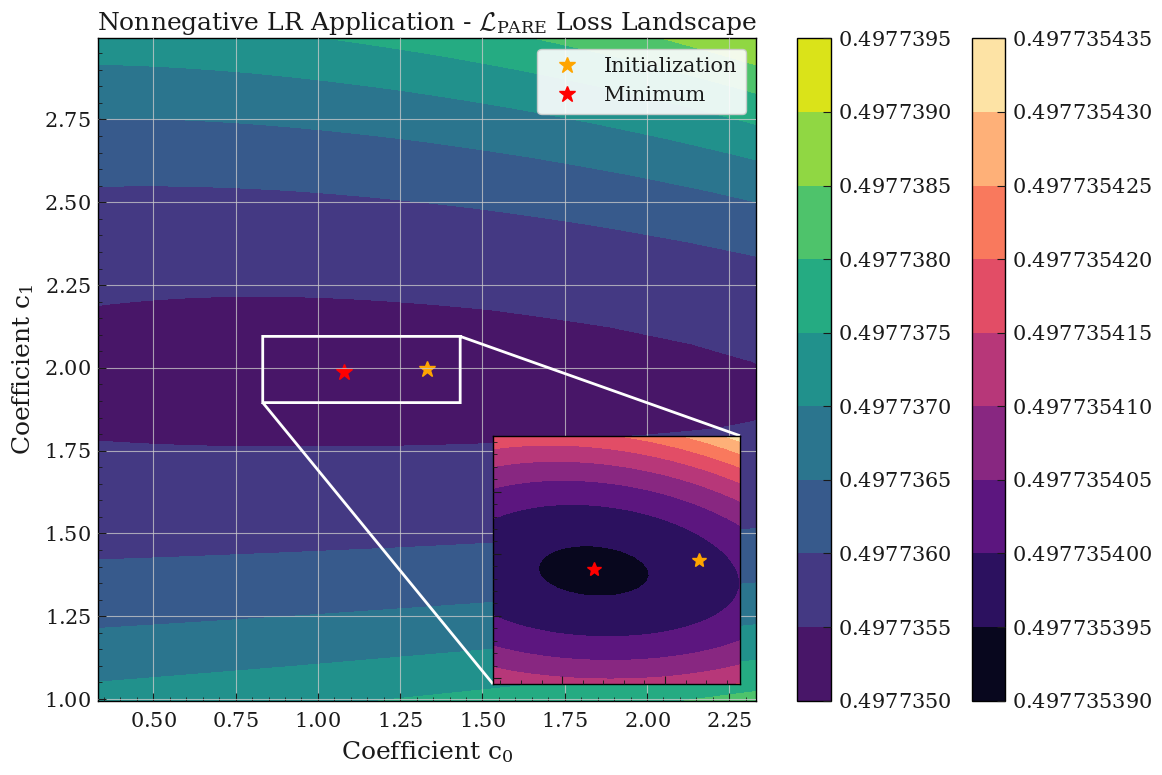

In [83]:
fig, ax = plt.subplots()
fig.set_size_inches(12,8)

xx, yy = np.meshgrid(x,y)
im = ax.contourf(xx, yy, pare_losses.T)#, levels=np.linspace(-1e6, 1e6, 15))
ax.plot(*coefficient_init, '*', c='orange', label="Initialization", markersize='12')
ax.plot(x2[pare_argmin2//N], y2[pare_argmin2%N], '*', c='red', label="Minimum", markersize='12')

axins = ax.inset_axes(
    [x.max()-0.8, y.min()+0.05, 0.75, 0.75],
    xlim=(x2.min(), x2.max()), ylim=(y2.min(), y2.max()),
    xticklabels=[], yticklabels=[], transform=ax.transData
)

xx2, yy2 = np.meshgrid(x2,y2)
im2 = axins.contourf(xx2, yy2, pare_losses2.T, cmap=matplotlib.colormaps['magma'])#, levels=np.linspace(-1e6, 1e6, 15))
axins.plot(*coefficient_init, '*', c='orange', label="Initialization", markersize='10')
axins.plot(x2[pare_argmin2//N], y2[pare_argmin2%N], '*', c='red', label="Minimum", markersize='10')
ax.indicate_inset_zoom(axins, edgecolor="white", linewidth=2, alpha=1)

ax.set_xlabel('Coefficient $c_0$', fontsize=18)
ax.set_ylabel('Coefficient $c_1$', fontsize=18)
if DATASET == "negative":
    ax.set_title("Signed LR Application - $\mathcal{L}_{PARE}$ Loss Landscape", fontsize=20)
if DATASET == "mc":
    ax.set_title("Nonnegative LR Application - $\mathcal{L}_{PARE}$ Loss Landscape", fontsize=18)
ax.grid(alpha=0.75)
ax.legend(frameon=True, framealpha=0.9, fontsize=15)
fig.colorbar(im2, ax=ax)
fig.colorbar(im, ax=ax)

fig.tight_layout()
# if DATASET == "mc":
#     fig.savefig("Toy_prob_pare_loss_landscape_inset.pdf")
# if DATASET == "negative":
#     fig.savefig("Toy_quasi_pare_loss_landscape_inset.pdf")

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_250778/3648649387.py:24: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("Signed LR Application - $\mathcal{L}_{REVERT}$ Loss Landscape", fontsize=20)
/tmp/ipykernel_250778/3648649387.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("Nonnegative LR Application - $\mathcal{L}_{REVERT}$ Loss Landscape", fontsize=18)


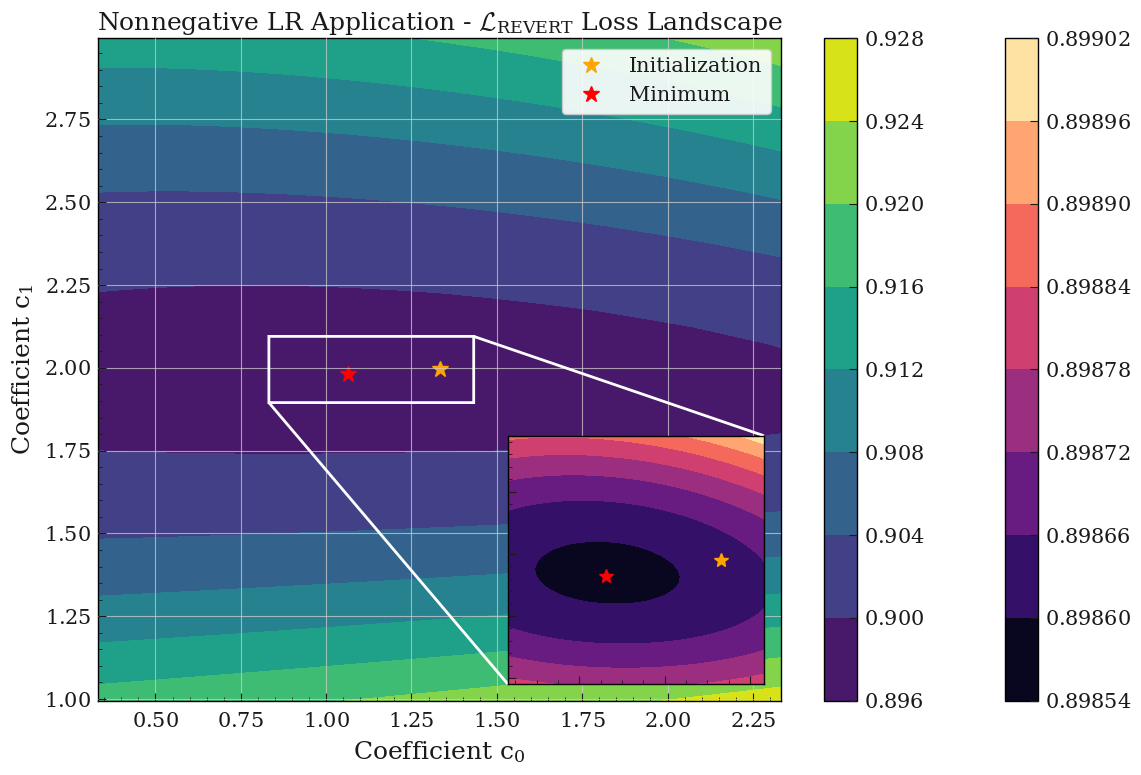

In [84]:
fig, ax = plt.subplots()
fig.set_size_inches(12,8)

xx, yy = np.meshgrid(x,y)
im = ax.contourf(xx, yy, revert_losses.T)#, levels=np.linspace(-1e6, 1e6, 15))
ax.plot(*coefficient_init, '*', c='orange', label="Initialization", markersize='12')
ax.plot(x2[revert_argmin2//N], y2[revert_argmin2%N], '*', c='red', label="Minimum", markersize='12')

axins = ax.inset_axes(
    [x.max()-0.8, y.min()+0.05, 0.75, 0.75],
    xlim=(x2.min(), x2.max()), ylim=(y2.min(), y2.max()),
    xticklabels=[], yticklabels=[], transform=ax.transData
)

xx2, yy2 = np.meshgrid(x2,y2)
im2 = axins.contourf(xx2, yy2, revert_losses2.T, cmap=matplotlib.colormaps['magma'])#, levels=np.linspace(-1e6, 1e6, 15))
axins.plot(*coefficient_init, '*', c='orange', label="Initialization", markersize='10')
axins.plot(x2[revert_argmin2//N], y2[revert_argmin2%N], '*', c='red', label="Minimum", markersize='10')
ax.indicate_inset_zoom(axins, edgecolor="white", linewidth=2, alpha=1)

ax.set_xlabel('Coefficient $c_0$', fontsize=18)
ax.set_ylabel('Coefficient $c_1$', fontsize=18)
if DATASET == "negative":
    ax.set_title("Signed LR Application - $\mathcal{L}_{REVERT}$ Loss Landscape", fontsize=20)
if DATASET == "mc":
    ax.set_title("Nonnegative LR Application - $\mathcal{L}_{REVERT}$ Loss Landscape", fontsize=18)
ax.grid(alpha=0.75)
ax.legend(frameon=True, framealpha=0.9, fontsize=15)
fig.colorbar(im2, ax=ax)
fig.colorbar(im, ax=ax)

fig.tight_layout()
# if DATASET == "mc":
#     fig.savefig("Toy_prob_revert_loss_landscape_inset.pdf")
# if DATASET == "negative":
#     fig.savefig("Toy_quasi_revert_loss_landscape_inset.pdf")